Name : W. K. D. D. Senuruk  
## Blobs & Fitting Basics

#### Laplacian of Gaussian (LoG)

Applying laplacian operator on gaussian function,

$$
\nabla^2 = \frac{\partial^2}{\partial x^2} + \frac{\partial^2}{\partial y^2}
$$

Getting the second partial derivatives of the gaussian with respect to x and y, and then combining them to form the laplacian of the gaussian,

$$
\begin{aligned}
\frac{\partial^2 G}{\partial x^2}
&= \frac{\partial}{\partial x} \left[ G(x, y) \cdot \left( -\frac{x}{\sigma^2} \right) \right] = G(x, y) \cdot \left( \frac{x^2 - \sigma^2}{\sigma^4} \right)
\end{aligned}

\quad \quad \quad \quad \quad \quad

\begin{aligned}
\frac{\partial^2 G}{\partial x^2}
&= \frac{\partial}{\partial x} \left[ G(x, y) \cdot \left( -\frac{x}{\sigma^2} \right) \right] = G(x, y) \cdot \left( \frac{x^2 - \sigma^2}{\sigma^4} \right)
\end{aligned}
$$


$$
\text{LoG}(x, y) = \left( \frac{x^2 + y^2 - 2\sigma^2}{\sigma^4} \right) \cdot \frac{1}{2\pi\sigma^2} \cdot \exp\left( -\frac{x^2 + y^2}{2\sigma^2} \right)
$$

Scale-normalized laplacian of gaussian,

$$
\sigma^2 \nabla^2 G(x, y, \sigma)
$$

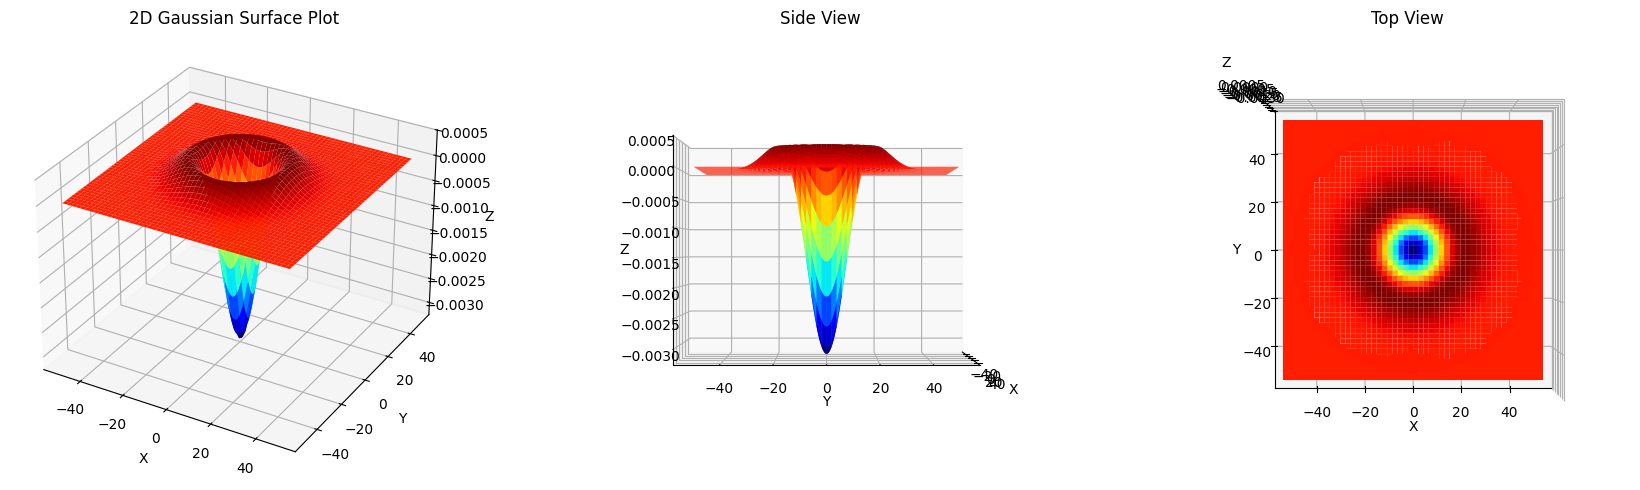

In [98]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

sigma = 10
spacial_resolution = 0.1
x = np.arange(-50, 50, spacial_resolution)
y = np.arange(-50, 50, spacial_resolution)
X, Y = np.meshgrid(x, y)
LoG = sigma**2 * ((X**2 + Y**2 - 2*sigma**2)/sigma**4)*(1/(2*np.pi*sigma**2))*np.exp(-(X**2+Y**2)/(2*sigma**2))

fig = plt.figure(figsize=(18, 5))

# main view
ax = fig.add_subplot(1, 3, 1, projection='3d')
surf = ax.plot_surface(X, Y, LoG, cmap='jet')
ax.set_title("2D Gaussian Surface Plot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# side view
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, LoG, cmap='jet')
ax2.view_init(elev=0, azim=0)  # side view from the x-direction
ax2.set_title("Side View")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")

# top view
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
surf3 = ax3.plot_surface(X, Y, LoG, cmap='jet')
ax3.view_init(elev=90, azim=-90)  # directly overhead
ax3.set_title("Top View")
ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")

plt.tight_layout()
plt.show()

#### Filtering images with LoG kernals

Creating an image of a black circle of radius 14

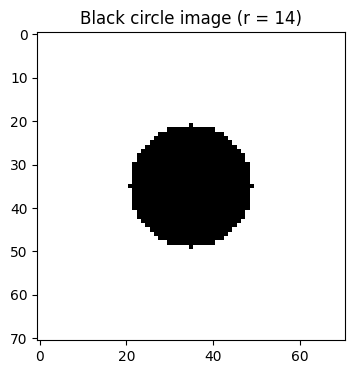

In [99]:
w, h = 71, 71
wc, hc = w//2, h//2
r = 14

x = np.arange(-wc, wc+1, 1)
y = np.arange(-hc, hc+1, 1)
X, Y = np.meshgrid(x, y)

image = np.ones((h, w), dtype=np.float32) * 255
image *= X**2 +Y**2 > r**2
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.title("Black circle image (r = 14)")
plt.show()

Let's filter the black circle image with a series of LoG kernals to find the scale-space extremum

Maximum response across all scales of sigma...
Pixel y : 35 ,    Pixel x : 35 ,    Sigma value : 10


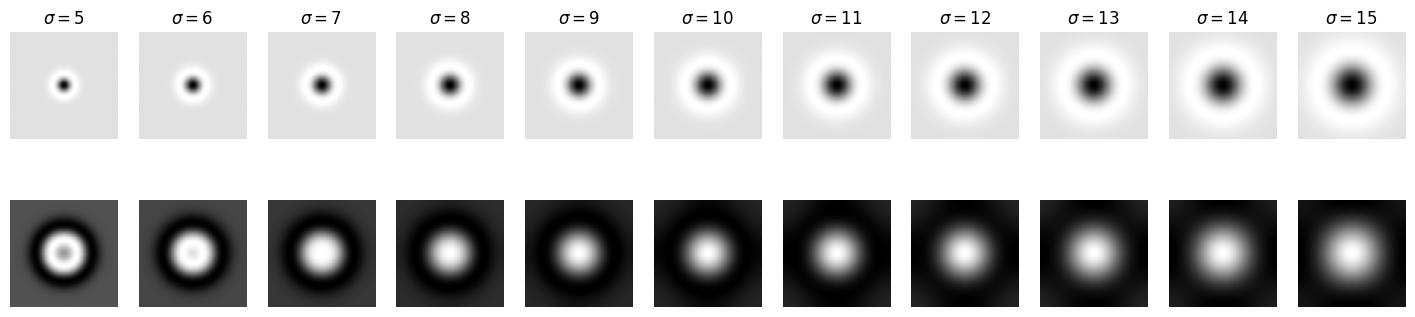

In [109]:
import cv2 as cv

s = 11
sigma = np.arange(5, 16, 1)
scale_space = np.empty((h, w, s), dtype=np.float32)

fig, ax = plt.subplots(2, 11, figsize=(18, 4))
for i in range(sigma.shape[0]):
    sigma_ = sigma[i]
    LoG_hw = 3*np.max(sigma)

    x = np.arange(-LoG_hw, LoG_hw+1, 1)
    y = np.arange(-LoG_hw, LoG_hw+1, 1)
    X, Y = np.meshgrid(x, y)
    LoG = sigma_**2 * ((X**2 + Y**2 - 2*sigma_**2)/sigma_**4)*(1/(2*np.pi*sigma_**2))*np.exp(-(X**2+Y**2)/(2*sigma_**2))
    image_LoG = cv.filter2D(image, -1, LoG)
    scale_space[:, :, i] = image_LoG

    ax[0, i].imshow(LoG, cmap="gray")
    ax[0, i].set_title('$\\sigma = {}$'.format(sigma_))
    ax[0, i].axis("off")
    ax[1, i].imshow(image_LoG, cmap="gray")
    ax[1, i].axis("off")

indices = np.unravel_index(np.argmax(scale_space, axis=None), scale_space.shape)
print("Maximum response across all scales of sigma...")
print("Pixel y :", indices[0], ",    Pixel x :", indices[1], ",    Sigma value :", sigma[indices[2]])